# Sequence Labeling Model Results Visualization

In [ ]:
import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [ ]:
def load_results(results_base_path="tnqeet/dotting_models/sequence_labeling/evaluation_results", dataset_type="val_dataset"):
    results_path = os.path.join(results_base_path, dataset_type)
    data = []
    
    for result_file in glob.glob(os.path.join(results_path, "*.json")):
        filename = os.path.basename(result_file)
        parts = filename.replace('_results.json', '').split('_')
        model_name = parts[0]
        n_layers = int(parts[2])
        
        with open(result_file, 'r', encoding='utf-8') as f:
            results = json.load(f)
        
        if not results:
            continue
        
        avg_wer = sum(r["wer"] for r in results) / len(results)
        avg_cer = sum(r["cer"] for r in results) / len(results)
        avg_doer = sum(r["doer"] for r in results) / len(results)
        
        def parse_time(time_str):
            try:
                if isinstance(time_str, str) and ":" in time_str:
                    parts = time_str.split(":")
                    hours, minutes = int(parts[0]), int(parts[1])
                    seconds = float(parts[2])
                    return hours * 3600 + minutes * 60 + seconds
                return float(time_str)
            except:
                return 0.0
        
        per_char_times_ms = [
            (parse_time(r["dotting_time"]) * 1000) / len(r["dotless_text"])
            for r in results if len(r["dotless_text"]) > 0
        ]
        avg_time_per_char_ms = sum(per_char_times_ms) / len(per_char_times_ms)
        
        data.append({
            "Model": model_name,
            "Layers": n_layers,
            "WER": f"{avg_wer:.4f}",
            "CER": f"{avg_cer:.4f}",
            "DOER": f"{avg_doer:.4f}",
            "Cost (ms/char)": f"{avg_time_per_char_ms:.4f}"
        })
    
    df = pd.DataFrame(data)
    if not df.empty:
        df = df.sort_values('Layers')
    return df

## Validation val Results

In [ ]:
val_df = load_results(dataset_type="val_dataset")
print(tabulate(val_df, headers='keys', tablefmt='grid', showindex=False))

+---------+----------+--------+--------+--------+---------------------------+
| Model   |   Layers |    WER |    CER |   DOER |   Inference Time (s/char) |
+=========+==========+========+========+========+===========================+
| LSTM    |        1 | 0.0969 | 0.0187 | 0.0222 |                  5.9e-05  |
+---------+----------+--------+--------+--------+---------------------------+
| LSTM    |        2 | 0.0634 | 0.0124 | 0.0147 |                  8.6e-05  |
+---------+----------+--------+--------+--------+---------------------------+
| LSTM    |        3 | 0.0611 | 0.0118 | 0.014  |                  0.000116 |
+---------+----------+--------+--------+--------+---------------------------+
| LSTM    |        4 | 0.0566 | 0.0108 | 0.0129 |                  0.000145 |
+---------+----------+--------+--------+--------+---------------------------+
| LSTM    |        5 | 0.0543 | 0.0103 | 0.0122 |                  0.000181 |
+---------+----------+--------+--------+--------+---------------

In [ ]:
def plot_results(df, dataset_name="val_dataset", figsize=(10, 6)):
    if df.empty:
        print("No data to plot")
        return
    
    df_plot = df.copy()
    df_plot['WER_numeric'] = df_plot['WER'].astype(float)
    df_plot['CER_numeric'] = df_plot['CER'].astype(float)
    df_plot['DOER_numeric'] = df_plot['DOER'].astype(float)
    df_plot['Cost_numeric'] = df_plot['Cost (ms/char)'].astype(float)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=figsize)
    
    x = df_plot['Layers']
    width = 0.25
    x_pos = np.arange(len(x))
    
    ax.bar(x_pos - width, df_plot['WER_numeric'], width, label='WER', 
           color='#e74c3c', alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.bar(x_pos, df_plot['CER_numeric'], width, label='CER', 
           color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.bar(x_pos + width, df_plot['DOER_numeric'], width, label='DOER', 
           color='#2ecc71', alpha=0.8, edgecolor='white', linewidth=1.5)
    
    ax.set_xlabel('Number of LSTM Layers', fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Sequence Labeling Performance - {dataset_name.replace("_", " ").title()}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    ax2 = ax.twinx()
    ax2.plot(x_pos, df_plot['Cost_numeric'], color='#8e44ad', marker='o',
             linewidth=2, markersize=8, label='Cost (ms/char)')
    ax2.set_ylabel('Cost (ms/char)', fontsize=12, fontweight='bold', color='#8e44ad')
    ax2.tick_params(axis='y', labelcolor='#8e44ad')
    ax2.grid(False)
    
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')
    
    plt.tight_layout()
    
    os.makedirs('tnqeet/dotting_models/sequence_labeling/visualization_figures', exist_ok=True)
    output_path = f'tnqeet/dotting_models/sequence_labeling/visualization_figures/{dataset_name}_results.pdf'
    plt.savefig(output_path, dpi=300, bbox_inches='tight', format='pdf')
    print(f"Figure saved to: {output_path}")
    
    plt.show()

Figure saved to: tnqeet/dotting_models/sequence_labeling/visualization_figures/val_dataset_results.pdf


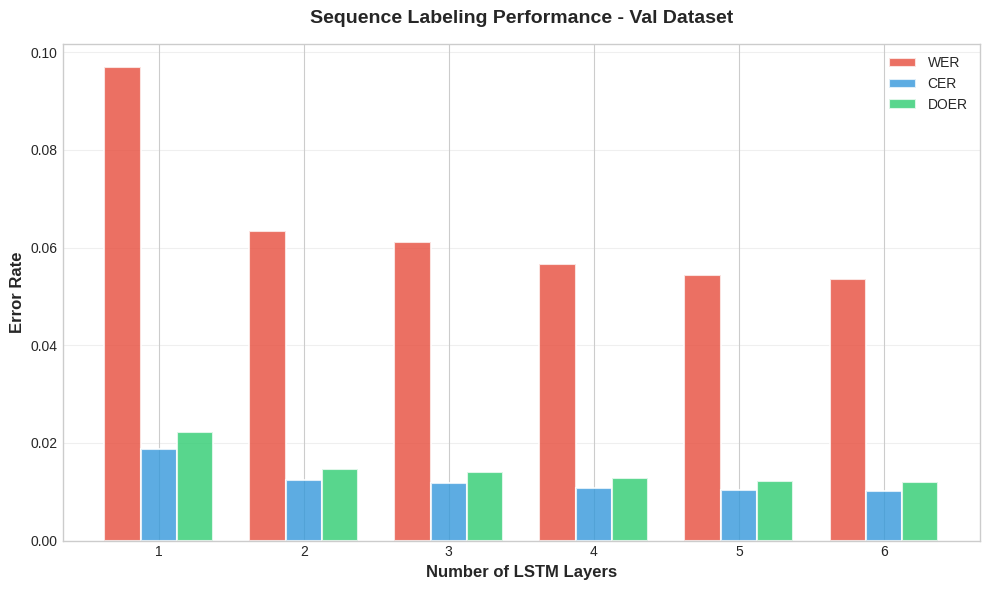

In [ ]:
plot_results(val_df, dataset_name="val_dataset")

## Test Results

In [ ]:
test_df = load_results(dataset_type="test_dataset")
print(tabulate(test_df, headers='keys', tablefmt='grid', showindex=False))

+---------+----------+--------+--------+--------+----------------------+
| Model   |   Layers |    WER |    CER |   DOER |   Inference Time (s) |
+=========+==========+========+========+========+======================+
| LSTM    |        1 | 0.1268 | 0.0244 | 0.0283 |               0.0346 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        2 | 0.0921 | 0.0177 | 0.0206 |               0.0611 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        3 | 0.0887 | 0.0171 | 0.0198 |               0.0901 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        4 | 0.0849 | 0.0162 | 0.0187 |               0.1169 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        5 | 0.0826 | 0.0157 | 0.0181 |               0.1465 |
+---------+----------+--------+--------+--------+----------------------+
| LSTM    |        6 | 0.0843 | 0.0159 | 0.0184 |  

Figure saved to: tnqeet/dotting_models/sequence_labeling/visualization_figures/test_dataset_results.pdf


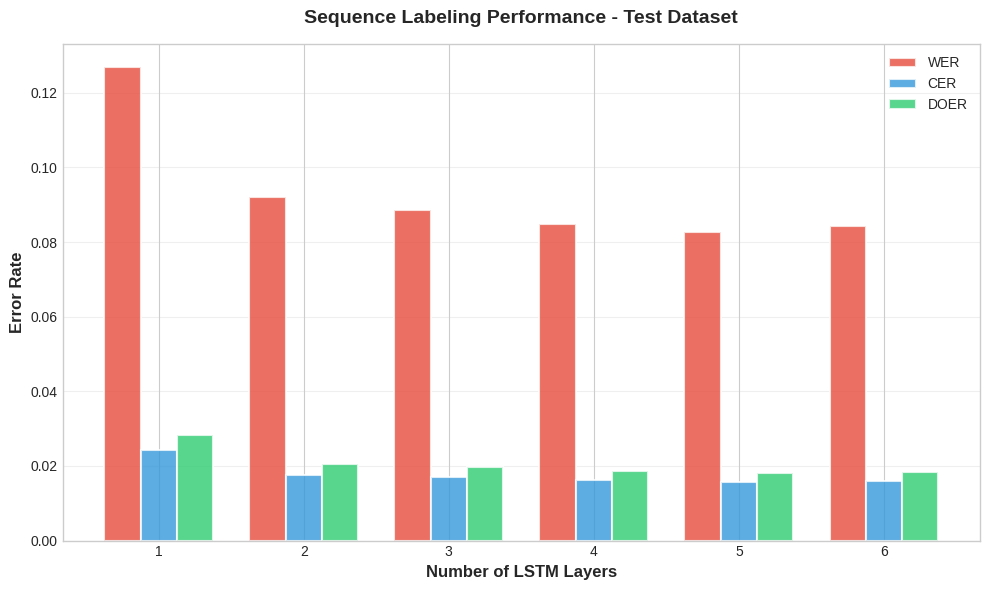

In [ ]:
plot_results(test_df, dataset_name="test_dataset")